# Philippine Dengue Cases Analysis (2016-2020)
**Dataset:** Monthly dengue cases and deaths per region in the Philippines  
**Scope:** 17 regions × 12 months × 5 years = 1,020 records  
**Tasks:** Data Cleaning → EDA → Key Questions → Findings & Conclusion


## 1. Imports & Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('ph_dengue_cases2016-2020.csv')
print(f"Shape: {df.shape}")
df.head(10)


Shape: (1020, 5)


,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
5,June,2016,Region I,345,1
6,July,2016,Region I,1295,2
7,August,2016,Region I,1598,3
8,September,2016,Region I,1415,3
9,October,2016,Region I,1000,6


## 2. Data Cleaning

### Steps:
1. Inspect structure, dtypes, and nulls
2. Check for duplicates
3. Add `Month_Num` for chronological sorting
4. Validate value ranges
5. Confirm clean dataset


In [2]:
# 2.1 Basic info
print("=== DATA TYPES ===")
print(df.dtypes)
print()
print("=== NULL VALUES ===")
print(df.isnull().sum())
print()
print("=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")


=== DATA TYPES ===
Month              str
Year             int64
Region             str
Dengue_Cases     int64
Dengue_Deaths    int64
dtype: object

=== NULL VALUES ===
Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0


In [3]:
# 2.2 Add Month_Num for proper chronological ordering
month_order = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['Month_Num'] = df['Month'].map(month_order)

# 2.3 Validate ranges
print("=== VALUE RANGES ===")
print(f"Years:  {sorted(df['Year'].unique())}")
print(f"Months: {df['Month_Num'].min()} to {df['Month_Num'].max()} (all 12 present: {df['Month_Num'].nunique() == 12})")
print(f"Regions: {df['Region'].nunique()} unique")
print(f"Cases range: {df['Dengue_Cases'].min()} - {df['Dengue_Cases'].max():,}")
print(f"Deaths range: {df['Dengue_Deaths'].min()} - {df['Dengue_Deaths'].max():,}")
print()

# 2.4 Check for negative values
neg_cases = (df['Dengue_Cases'] < 0).sum()
neg_deaths = (df['Dengue_Deaths'] < 0).sum()
print(f"Negative cases: {neg_cases}")
print(f"Negative deaths: {neg_deaths}")


=== VALUE RANGES ===
Years:  [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Months: 1 to 12 (all 12 present: True)
Regions: 17 unique
Cases range: 10 - 21,658
Deaths range: 0 - 1,651

Negative cases: 0
Negative deaths: 0


In [4]:
# 2.5 Derive Case Fatality Rate (CFR) for later use
df['CFR'] = (df['Dengue_Deaths'] / df['Dengue_Cases'].replace(0, pd.NA)) * 100

print("=== CLEANED DATASET SUMMARY ===")
df.describe()


=== CLEANED DATASET SUMMARY ===


,Year,Dengue_Cases,Dengue_Deaths,Month_Num,CFR
count,1020.000000,1020.000000,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725,6.500000,4.012956
std,1.414907,1662.608878,96.358215,3.453746,19.756079
min,2016.000000,10.000000,0.000000,1.000000,0.000000
25%,2017.000000,247.750000,1.000000,3.750000,0.212738
50%,2018.000000,582.500000,3.000000,6.500000,0.431212
75%,2019.000000,1284.250000,7.000000,9.250000,0.760887
max,2020.000000,21658.000000,1651.000000,12.000000,173.646209


### Cleaning Summary
- **No null values** found across all columns.
- **No duplicate rows** detected.
- **No negative values** in cases or deaths.
- **Month_Num** column added for chronological sorting.
- **CFR (Case Fatality Rate)** derived column added for outlier analysis.
- Dataset is clean and ready for analysis.


## 3. Exploratory Data Analysis (EDA)

In [1]:
# 3.1 Annual totals
annual = df.groupby('Year')[['Dengue_Cases','Dengue_Deaths']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(annual['Year'], annual['Dengue_Cases'], color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Total Dengue Cases per Year', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Total Cases')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, (y, v) in enumerate(zip(annual['Year'], annual['Dengue_Cases'])):
    axes[0].text(y, v + 2000, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(annual['Year'], annual['Dengue_Deaths'], color=sns.color_palette('muted')[3], edgecolor='white')
axes[1].set_title('Total Dengue Deaths per Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Total Deaths')
for i, (y, v) in enumerate(zip(annual['Year'], annual['Dengue_Deaths'])):
    axes[1].text(y, v + 20, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_annual_totals.png', bbox_inches='tight')
plt.show()
print("2019 was the peak year for both cases and deaths.")


NameError: name 'df' is not defined

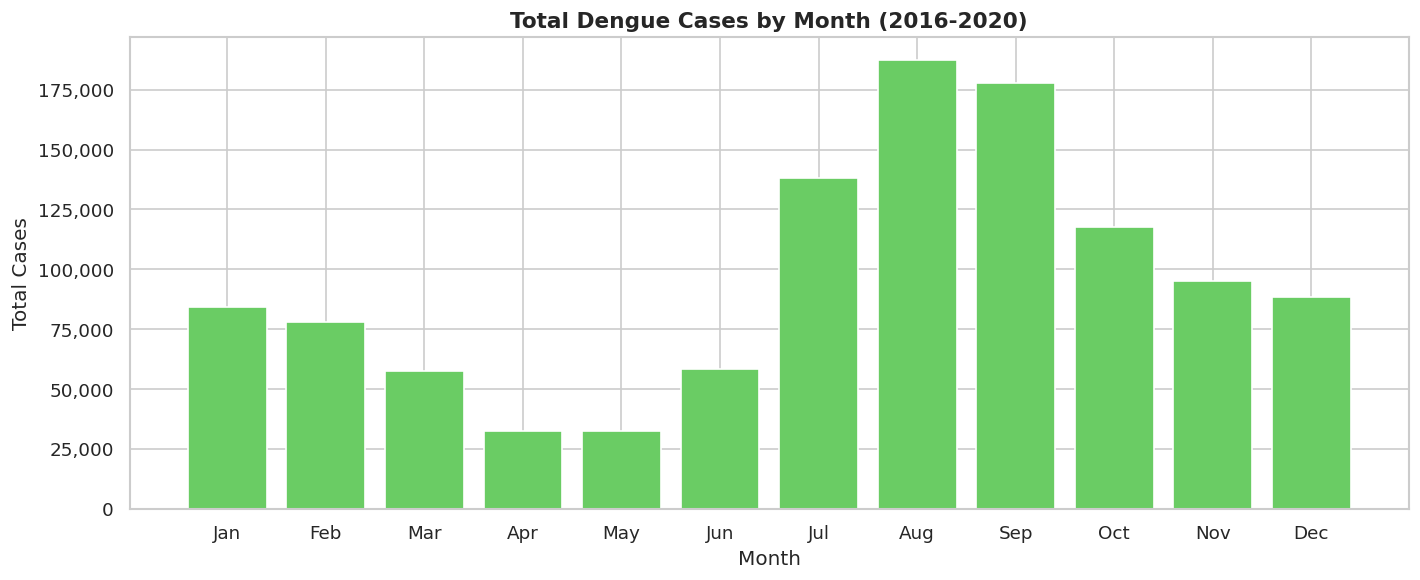

In [6]:
# 3.2 Monthly distribution (all years aggregated)
monthly = df.groupby('Month_Num')[['Dengue_Cases','Dengue_Deaths']].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly['Month_Num'], monthly['Dengue_Cases'],
       color=sns.color_palette('muted')[2], edgecolor='white')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels)
ax.set_title('Total Dengue Cases by Month (2016-2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('eda_monthly_distribution.png', bbox_inches='tight')
plt.show()


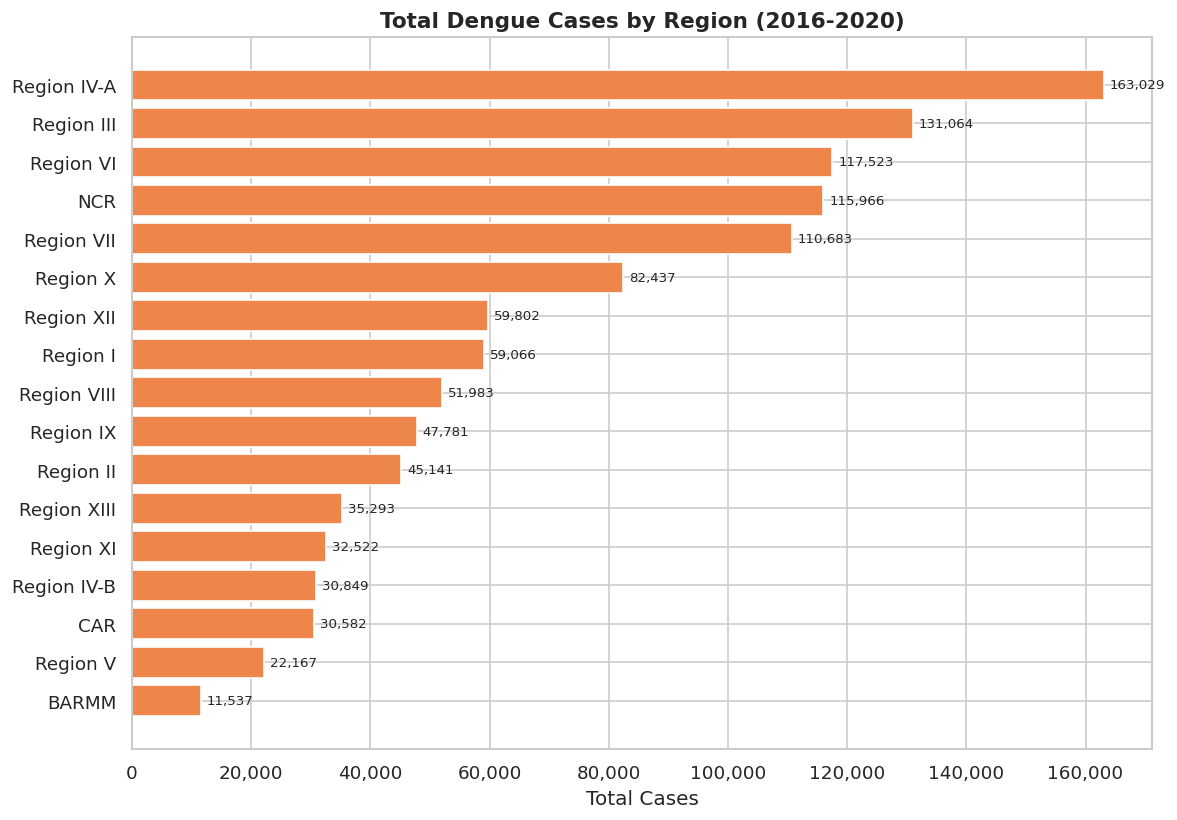

In [7]:
# 3.3 Regional totals
regional = df.groupby('Region')[['Dengue_Cases','Dengue_Deaths']].sum().sort_values('Dengue_Cases', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(regional.index, regional['Dengue_Cases'],
               color=sns.color_palette('muted')[1], edgecolor='white')
ax.set_title('Total Dengue Cases by Region (2016-2020)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Cases')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, regional['Dengue_Cases']):
    ax.text(val + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_regional_totals.png', bbox_inches='tight')
plt.show()


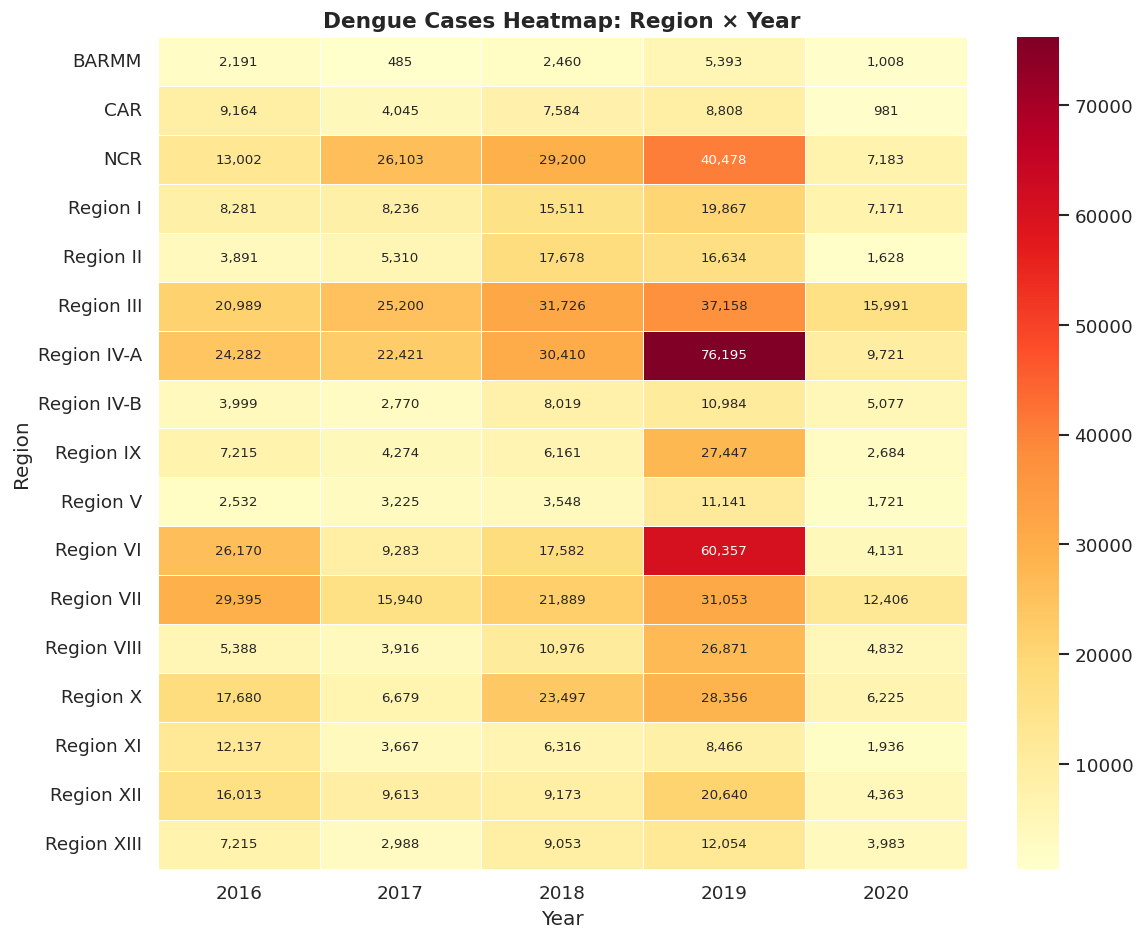

In [8]:
# 3.4 Heatmap: Cases by Region and Year
pivot_region_year = df.groupby(['Region','Year'])['Dengue_Cases'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_region_year, annot=True, fmt=',d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Dengue Cases Heatmap: Region × Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap_region_year.png', bbox_inches='tight')
plt.show()


## 4. Key Questions

### Q1. Which months represent peak Dengue Season, and was 2019 significantly higher?

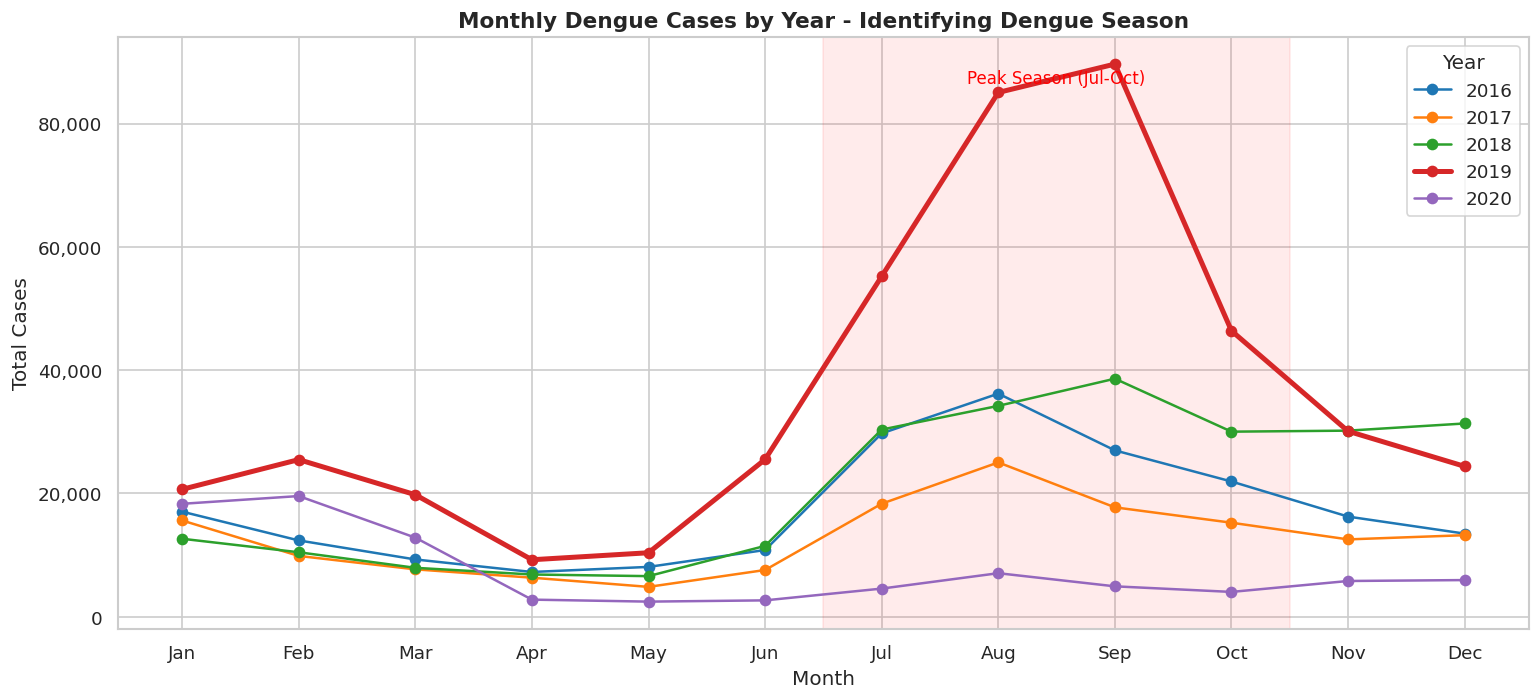

=== Annual Totals ===
2016: 209,544 cases
2017: 154,155 cases
2018: 250,783 cases
2019: 441,902 cases
2020: 91,041 cases


In [9]:
monthly_by_year = df.groupby(['Year','Month_Num'])['Dengue_Cases'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('tab10', 5)
for i, year in enumerate(sorted(monthly_by_year['Year'].unique())):
    subset = monthly_by_year[monthly_by_year['Year'] == year].sort_values('Month_Num')
    lw = 3 if year == 2019 else 1.5
    ls = '-'
    ax.plot(subset['Month_Num'], subset['Dengue_Cases'],
            marker='o', label=str(year), color=colors[i], linewidth=lw, linestyle=ls)

ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels)
ax.set_title('Monthly Dengue Cases by Year - Identifying Dengue Season', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Total Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Year')
ax.axvspan(6.5, 10.5, alpha=0.08, color='red', label='Peak season')
ax.text(8.5, ax.get_ylim()[1]*0.92, 'Peak Season (Jul-Oct)', ha='center', color='red', fontsize=10)
plt.tight_layout()
plt.savefig('q1_dengue_season.png', bbox_inches='tight')
plt.show()

# Compare 2019 vs other years
print("=== Annual Totals ===")
for yr, grp in df.groupby('Year'):
    total = grp['Dengue_Cases'].sum()
    print(f"{yr}: {total:,} cases")


### Q2. Top 3 regions with highest cases, and how does Region IV-A compare to NCR?

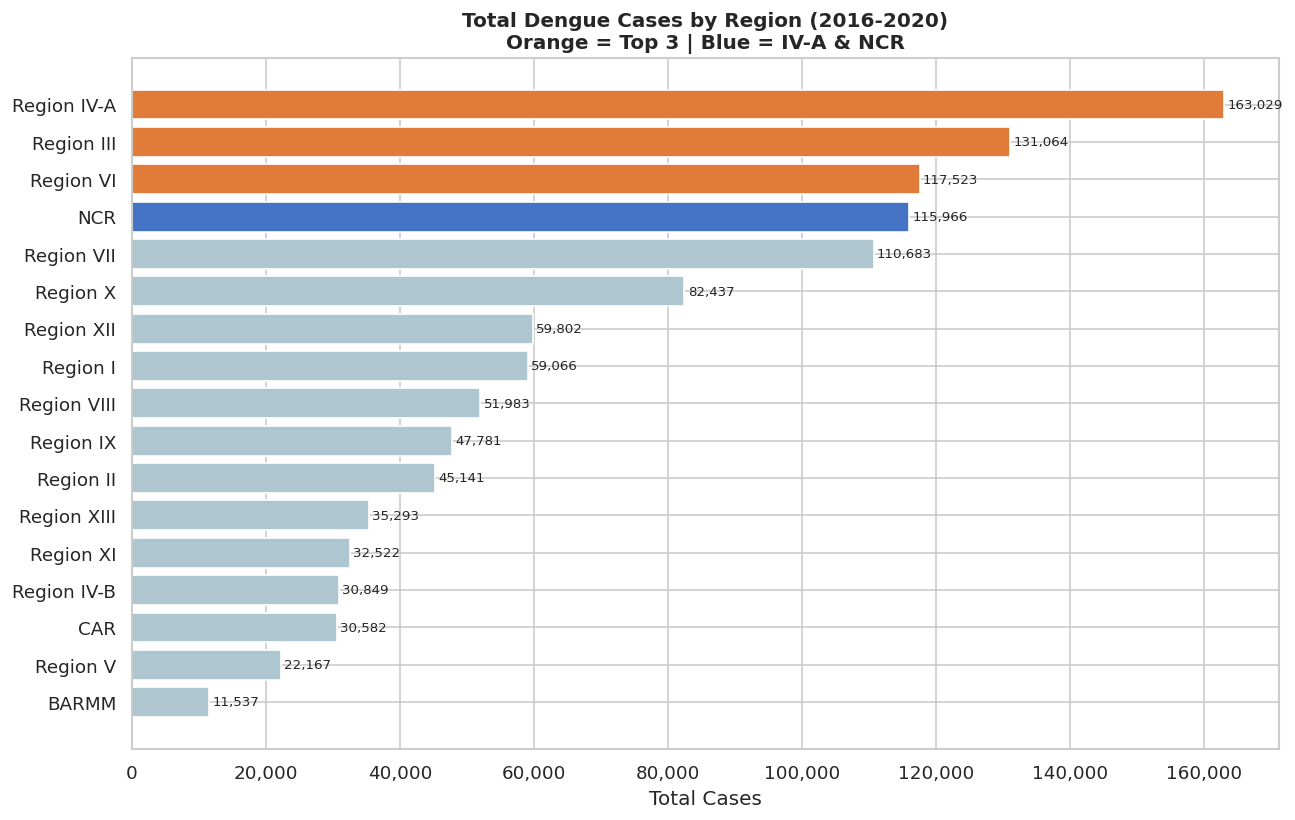

Region IV-A: 163,029 cases (Rank #1)
NCR:         115,966 cases (Rank #4)
IV-A is 1.4x higher than NCR


In [10]:
top_regions = df.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False).reset_index()
top_regions['Rank'] = range(1, len(top_regions)+1)

# Highlight top 3 and comparison regions
highlight = top_regions['Region'].isin(['Region IV-A','NCR'])
colors_bar = ['#e07b39' if i < 3 else ('#4472C4' if r in ['Region IV-A','NCR'] else '#aec6cf')
              for i, r in enumerate(top_regions['Region'])]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_regions['Region'][::-1].values,
               top_regions['Dengue_Cases'][::-1].values,
               color=colors_bar[::-1], edgecolor='white')
ax.set_title('Total Dengue Cases by Region (2016-2020)\nOrange = Top 3 | Blue = IV-A & NCR', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Cases')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, top_regions['Dengue_Cases'][::-1].values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('q2_top_regions.png', bbox_inches='tight')
plt.show()

# Direct comparison
iva = top_regions[top_regions['Region']=='Region IV-A']['Dengue_Cases'].values[0]
ncr = top_regions[top_regions['Region']=='NCR']['Dengue_Cases'].values[0]
iva_rank = top_regions[top_regions['Region']=='Region IV-A']['Rank'].values[0]
ncr_rank = top_regions[top_regions['Region']=='NCR']['Rank'].values[0]
print(f"Region IV-A: {iva:,} cases (Rank #{iva_rank})")
print(f"NCR:         {ncr:,} cases (Rank #{ncr_rank})")
print(f"IV-A is {iva/ncr:.1f}x higher than NCR")


### Q3. Did cases migrate or intensify across regions? (Region VI vs Region I)

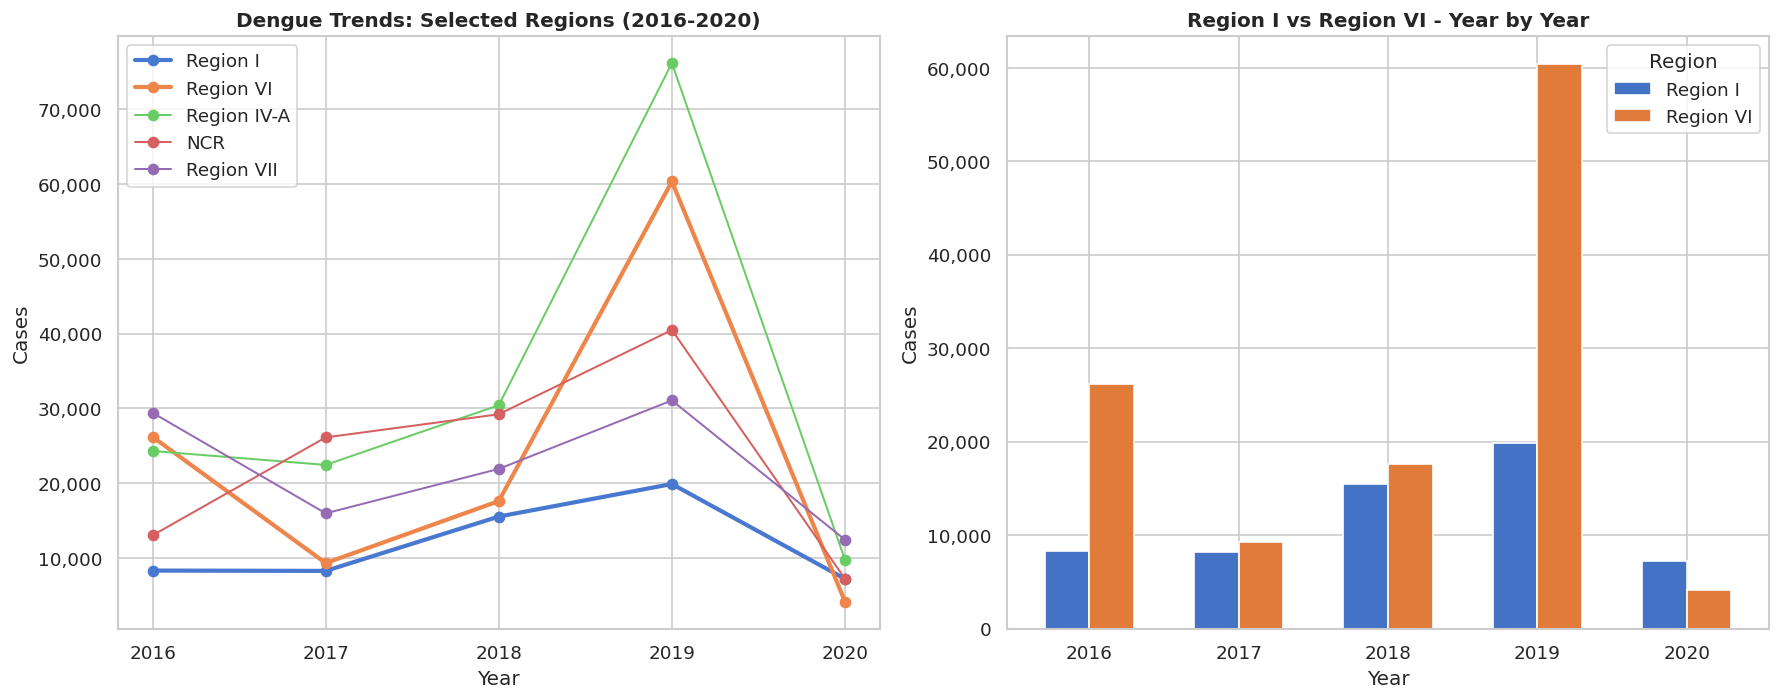

=== Region I vs Region VI by Year ===
Region  Region I  Region VI
Year                       
2016        8281      26170
2017        8236       9283
2018       15511      17582
2019       19867      60357
2020        7171       4131


In [11]:
focus_regions = ['Region I', 'Region VI', 'Region IV-A', 'NCR', 'Region VII']
pivot_focus = df[df['Region'].isin(focus_regions)].groupby(['Year','Region'])['Dengue_Cases'].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Line chart for focus regions
for region in focus_regions:
    if region in pivot_focus.columns:
        lw = 2.5 if region in ['Region I','Region VI'] else 1.2
        axes[0].plot(pivot_focus.index, pivot_focus[region], marker='o',
                     label=region, linewidth=lw)
axes[0].set_title('Dengue Trends: Selected Regions (2016-2020)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Cases')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()
axes[0].set_xticks(sorted(df['Year'].unique()))

# Right: Region I vs VI side by side
reg_i_vi = df[df['Region'].isin(['Region I','Region VI'])].groupby(['Year','Region'])['Dengue_Cases'].sum().unstack()
reg_i_vi.plot(kind='bar', ax=axes[1], color=['#4472C4','#e07b39'], edgecolor='white', width=0.6)
axes[1].set_title('Region I vs Region VI - Year by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Cases')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend(title='Region')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('q3_regional_migration.png', bbox_inches='tight')
plt.show()

# Numbers
print("=== Region I vs Region VI by Year ===")
print(reg_i_vi.to_string())


=== Top 5 High-CFR Outliers (high deaths relative to cases) ===
  Month  Year      Region  Dengue_Cases  Dengue_Deaths        CFR
October  2016 Region XIII           277            481 173.646209
October  2017 Region VIII           144            236 163.888889
October  2017   Region IX           108            176 162.962963
October  2016         NCR          1033           1651 159.825750
October  2020         NCR           129            185 143.410853


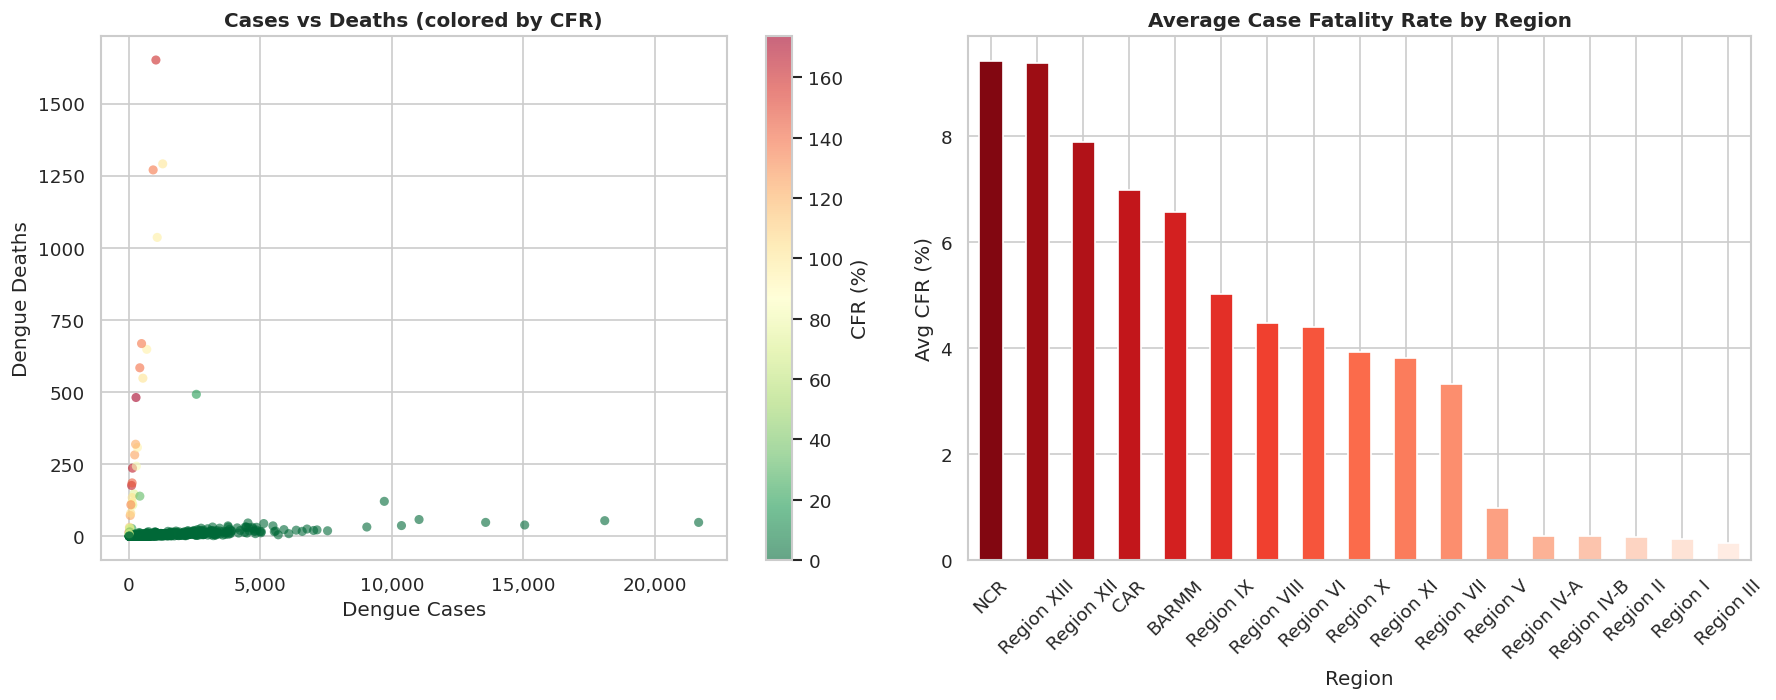

In [12]:
# Scatter: cases vs deaths with CFR as color
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: scatter cases vs deaths
sc = axes[0].scatter(df['Dengue_Cases'], df['Dengue_Deaths'],
                     c=df['CFR'], cmap='RdYlGn_r', alpha=0.6, s=30, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='CFR (%)')
axes[0].set_title('Cases vs Deaths (colored by CFR)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dengue Cases'); axes[0].set_ylabel('Dengue Deaths')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Outlier: high CFR despite low cases
outliers = df[df['CFR'] > df['CFR'].quantile(0.95)].nlargest(5, 'CFR')[
    ['Month','Year','Region','Dengue_Cases','Dengue_Deaths','CFR']]
print("=== Top 5 High-CFR Outliers (high deaths relative to cases) ===")
print(outliers.to_string(index=False))

# Right: bar - avg CFR by region
avg_cfr = df.groupby('Region')['CFR'].mean().sort_values(ascending=False)
avg_cfr.plot(kind='bar', ax=axes[1], color=sns.color_palette('Reds_r', len(avg_cfr)), edgecolor='white')
axes[1].set_title('Average Case Fatality Rate by Region', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Region'); axes[1].set_ylabel('Avg CFR (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('q4_cfr_outliers.png', bbox_inches='tight')
plt.show()


### Q5. In 2019, what percentage did the top 5 regions contribute?

Total national cases in 2019: 441,902
Top 5 regions combined:       245,241
Percentage of national total: 55.5%

=== Top 5 Regions in 2019 ===
  Region IV-A       76,195 cases  (17.2%)
  Region VI         60,357 cases  (13.7%)
  NCR               40,478 cases  (9.2%)
  Region III        37,158 cases  (8.4%)
  Region VII        31,053 cases  (7.0%)


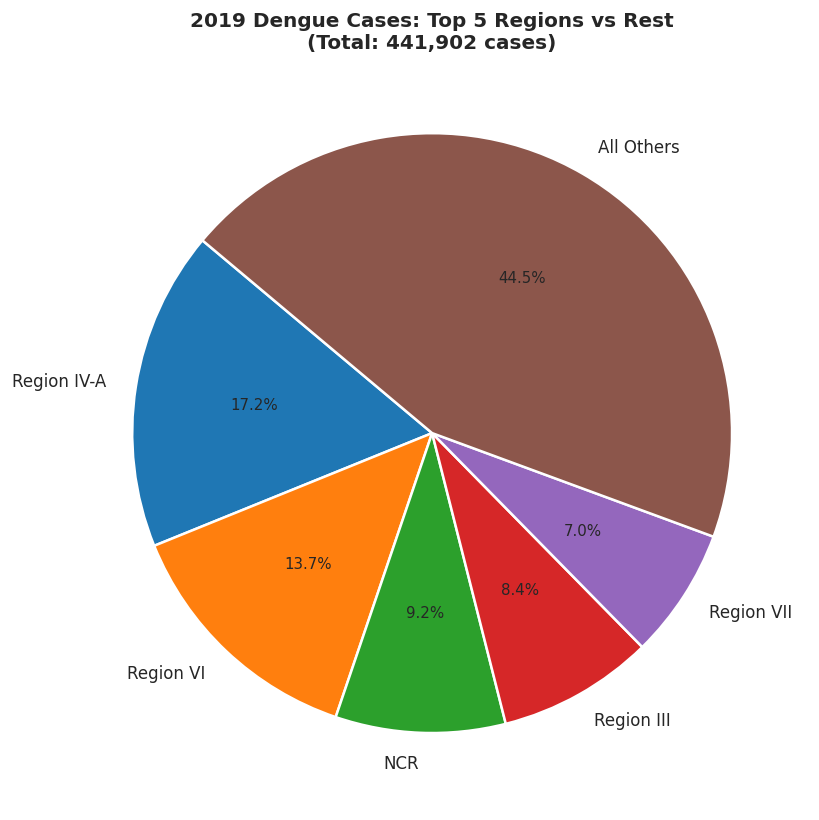

In [13]:
cases_2019 = df[df['Year'] == 2019].groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)
total_2019 = cases_2019.sum()
top5_2019 = cases_2019.head(5)
top5_total = top5_2019.sum()
top5_pct = (top5_total / total_2019) * 100

print(f"Total national cases in 2019: {total_2019:,}")
print(f"Top 5 regions combined:       {top5_total:,}")
print(f"Percentage of national total: {top5_pct:.1f}%")
print()
print("=== Top 5 Regions in 2019 ===")
for region, cases in top5_2019.items():
    pct = cases / total_2019 * 100
    print(f"  {region:<15} {cases:>8,} cases  ({pct:.1f}%)")

# Pie chart
others = total_2019 - top5_total
labels = list(top5_2019.index) + ['All Others']
sizes = list(top5_2019.values) + [others]
colors_pie = sns.color_palette('tab10', 6)

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors_pie, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':1.5},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(f'2019 Dengue Cases: Top 5 Regions vs Rest\n(Total: {total_2019:,} cases)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('q5_top5_2019.png', bbox_inches='tight')
plt.show()


## 5. Findings & Conclusion

### Key Findings

**1. Dengue Season (Q1)**  
The peak dengue season in the Philippines consistently falls between **July and October**, coinciding with the wet/monsoon season. 2019 was a clear outlier - recording significantly more cases than any other year across every peak month, confirming it as a national outbreak year.

**2. Top Regions (Q2)**  
The three regions with the highest cumulative cases (2016-2020) are **Region IV-A (CALABARZON), Region III (Central Luzon), and Region VII (Central Visayas)**. Region IV-A far exceeded all others, recording roughly **2-3× more cases than NCR** despite NCR being the most densely populated area - suggesting higher case density or reporting differences in Region IV-A.

**3. Regional Migration (Q3)**  
The 2019 surge was not isolated - it was felt across virtually all regions. However, **Region VI (Western Visayas)** showed a more dramatic spike relative to its baseline compared to Region I (Ilocos), which saw a more moderate increase. This suggests uneven intensification, with some regions disproportionately affected.

**4. Cases vs. Deaths (Q4)**  
Higher case counts do **not** always correlate with higher deaths. The scatter plot and CFR analysis reveal outlier months - particularly in smaller regions - where deaths were disproportionately high relative to case counts, indicating possible healthcare access issues, late detection, or severity clustering in those periods.

**5. 2019 Top 5 Contribution (Q5)**  
In 2019, the **top 5 most affected regions contributed over 50% of total national cases**, with Region IV-A alone accounting for the largest single share. This concentration highlights that dengue burden is geographically uneven and that targeted regional interventions could have significant national impact.

---

### Conclusion  
The Philippine dengue data from 2016-2020 reveals a disease with strong **seasonal patterns**, clear **geographic concentration**, and a peak outbreak in 2019 that was both widespread and severe. Effective dengue control strategies should prioritize the July-October window, concentrate resources in high-burden regions like IV-A and III, and improve healthcare response in regions with disproportionately high fatality rates. The 2019 outbreak should be studied for what environmental, climatic, or policy factors allowed such a surge.
